<a href="https://colab.research.google.com/github/dorcasojo/Machine-learning-Assignment/blob/main/Wine_Quality_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTING LIBRARIES**

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**LOADING DATASET**

In [17]:
data = pd.read_csv('/content/winequality.csv')

**CHECKING FOR MISSING VALUES**

In [6]:
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


** SPLIT DATASET**

In [7]:
X = data.drop("quality", axis=1)  # Input features
y = data["quality"]               # Output (target)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**DATA SCALING**

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler

StandardScaler()

**MODEL**

In [10]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error
    metrics=['mae']
)


**EPOCH**

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 9.5337 - mae: 2.4637 - val_loss: 2.9884 - val_mae: 1.2576
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0931 - mae: 1.1179 - val_loss: 2.2384 - val_mae: 1.0807
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5907 - mae: 0.9746 - val_loss: 1.6903 - val_mae: 0.9555
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2233 - mae: 0.8555 - val_loss: 1.2707 - val_mae: 0.8360
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9394 - mae: 0.7554 - val_loss: 0.9575 - val_mae: 0.7334
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7388 - mae: 0.6690 - val_loss: 0.7447 - val_mae: 0.6594
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6249 - mae: 0.6171 - val_loss: 0.6340 - val_mae: 0.6089
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5644 - mae: 0.5834 - val_loss: 0.5695 - val_mae: 0.5852
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [13]:
y_pred = model.predict(X_test)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


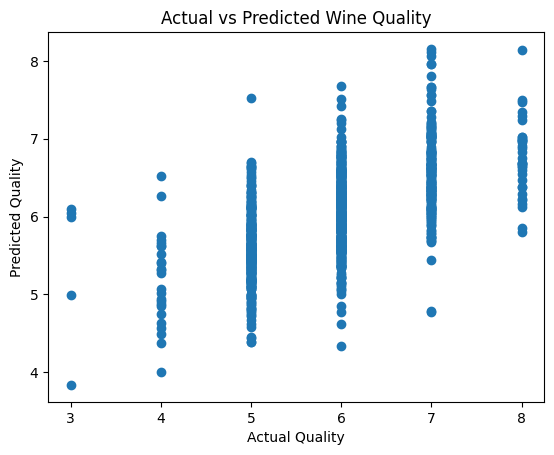

In [14]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

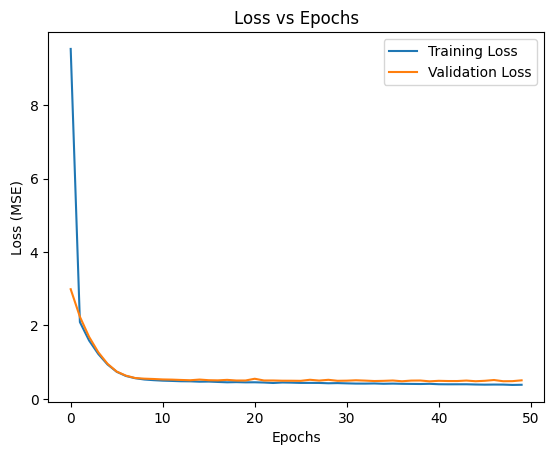

In [15]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()